In [10]:
#######################################################
#     CNN + Yolo como clasificador con CIFAR-10       #
#######################################################
#1. Instalamos los paquetes de ultralytics necesarios y el dataset de tensorflow
#!pip install ultralytics tensorflow tensorflow-datasets
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/CIFAR-10/train.csv")
y_train = train_df["label"].values
X_train = train_df.drop(columns=["label"]).values
X_train = X_train.reshape(-1, 32, 32, 3)
X_train = X_train.astype("float32") / 255.0

from keras.utils import to_categorical
y_train = to_categorical(y_train, 10)




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Esto libera:
# - pesos temporales
# - gradientes
# - grafo computacional
# - memoria de GPU/CPU

import gc
import tensorflow as tf

gc.collect()
tf.keras.backend.clear_session()

In [12]:
# Usamos el 20% final como validación pero no se pued usar porque no colab se queda sin memoria, así qu eseleccionamos un subconjunto
#val_size = int(0.2 * len(X_train))
#X_val = X_train[-val_size:]
#y_val = y_train[-val_size:]

subset = 200
X_small = X_train[:subset]
y_small = y_train[:subset]

# Convertir imágenes a formato YOLO (lista de arrays)
imgs = [img for img in X_small]

# Predicciones YOLO
#yolo_preds = yolo_cls.predict(imgs)

# Da error porque YOLO necesita :- formato uint8 ;- rango 0–255; - tipo PIL.Image
#- tamaño mínimo 32×32, pero idealmente 224×224 (como ImageNet)

from PIL import Image
import numpy as np

# Convertir imágenes a formato PIL y reescalar a 224x224
pil_imgs = []

for img in X_small:
    img_uint8 = (img * 255).astype(np.uint8)   # volver a 0–255
    pil_img = Image.fromarray(img_uint8)       # convertir a PIL
    pil_img = pil_img.resize((224, 224))       # YOLO usa 224x224
    pil_imgs.append(pil_img)


#Convertir predicciones YOLO a clases
import numpy as np

# Cargar modelo de clasificación
model = YOLO("yolov8n-cls.pt")

yolo_pred_classes = []

batch_size = 16
for i in range(0, len(pil_imgs), batch_size):
    batch = pil_imgs[i:i+batch_size]
    preds = model.predict(batch, stream=False)
    yolo_pred_classes.extend([p.probs.top1 for p in preds])


0: 224x224 spotted_salamander 0.15, magnetic_compass 0.12, nematode 0.08, paddlewheel 0.06, safety_pin 0.05, 10.1ms
1: 224x224 velvet 0.81, jaguar 0.06, leopard 0.02, prayer_rug 0.01, nematode 0.01, 10.1ms
2: 224x224 container_ship 0.30, hotdog 0.06, abacus 0.05, cradle 0.05, rotisserie 0.04, 10.1ms
3: 224x224 chiffonier 0.12, prayer_rug 0.08, nematode 0.06, rotisserie 0.05, letter_opener 0.04, 10.1ms
4: 224x224 letter_opener 0.31, ski 0.17, tobacco_shop 0.15, bassoon 0.08, shoe_shop 0.03, 10.1ms
5: 224x224 velvet 0.09, jaguar 0.07, Windsor_tie 0.04, fox_squirrel 0.04, leopard 0.04, 10.1ms
6: 224x224 velvet 0.55, safety_pin 0.05, prayer_rug 0.05, electric_ray 0.02, rock_beauty 0.02, 10.1ms
7: 224x224 safety_pin 0.36, letter_opener 0.09, rotisserie 0.07, prayer_rug 0.05, ski 0.03, 10.1ms
8: 224x224 jigsaw_puzzle 0.92, shoe_shop 0.02, quilt 0.01, safety_pin 0.01, letter_opener 0.00, 10.1ms
9: 224x224 bearskin 0.26, pool_table 0.07, drum 0.06, tobacco_shop 0.05, pirate 0.04, 10.1ms
10: 2

<Figure size 1000x1000 with 0 Axes>

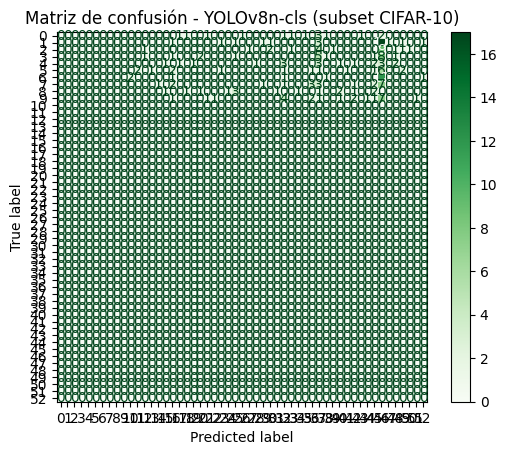

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = np.argmax(y_small, axis=1)
y_pred = np.array(yolo_pred_classes)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(10,10))
disp.plot(cmap='Greens', values_format='d')
plt.title("Matriz de confusión - YOLOv8n-cls (subset CIFAR-10)")
plt.show()


No se obtiene matriz de confusión ni metricas usando Yolo como clasificador con CIFAR-10 porque Yolo esta preentrenado con imagenNet y tiene 1000 clasesque no sirven para CIFAR-10, por tanto, deberíamos reentrenar YOLO con clases de CIFAR-10 y así obtendríamos metricas de entrenamiento y validación y matriz de confusión.